<a href="https://colab.research.google.com/github/fathanick/Text-analytics-course-UII/blob/main/Autoencoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Berikut adalah contoh implementasi Autoencoder sederhana menggunakan TensorFlow dan Keras, terinspirasi dari tautan GeeksforGeeks yang Anda berikan. Contoh ini akan melatih autoencoder untuk mengompres dan mendekompilasi citra digit dari dataset MNIST.

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

# Memuat dataset MNIST
(x_train, _), (x_test, _) = keras.datasets.mnist.load_data()

# Normalisasi dan reshape data
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))

print(f"Bentuk data training: {x_train.shape}")
print(f"Bentuk data testing: {x_test.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Bentuk data training: (60000, 784)
Bentuk data testing: (10000, 784)


### Definisi Model Autoencoder

Autoencoder terdiri dari dua bagian utama: Encoder dan Decoder.

*   **Encoder**: Mengambil input dan mengompresnya menjadi representasi berdimensi lebih rendah (disebut *latent space* atau *bottleneck*).
*   **Decoder**: Mengambil representasi dari *latent space* dan mencoba merekonstruksi input aslinya.

In [ ]:
# Ukuran input (28*28 = 784 untuk MNIST)
input_dim = x_train.shape[1]
# Ukuran dimensi latent space (botol leher)
latent_dim = 32

# ----- Encoder -----
encoder_input = keras.Input(shape=(input_dim,))
hx = layers.Dense(128, activation='relu')(encoder_input)
latent_output = layers.Dense(latent_dim, activation='relu')(hx)

encoder = keras.Model(encoder_input, latent_output, name='encoder')
encoder.summary()

# ----- Decoder -----
decoder_input = keras.Input(shape=(latent_dim,))
hx = layers.Dense(128, activation='relu')(decoder_input)
decoder_output = layers.Dense(input_dim, activation='sigmoid')(hx) # Sigmoid untuk output antara 0 dan 1

decoder = keras.Model(decoder_input, decoder_output, name='decoder')
decoder.summary()

# ----- Autoencoder Lengkap -----
autoencoder_input = keras.Input(shape=(input_dim,))
encoded = encoder(autoencoder_input)
decoded = decoder(encoded)

autoencoder = keras.Model(autoencoder_input, decoded, name='autoencoder')
autoencoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 104,608 (408.62 KB)

 Trainable params: 104,608 (408.62 KB)

 Non-trainable params: 0 (0.00 B)

...

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (Functional)            │ (None, 32)             │       104,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Functional)            │ (None, 784)            │       105,360 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 209,968 (820.19 KB)

 Trainable params: 209,968 (820.19 KB)

 Non-trainable params: 0 (0.00 B)

### Kompilasi dan Pelatihan Model

Kita akan menggunakan *Mean Squared Error* (MSE) sebagai fungsi kerugian karena kita ingin output rekonstruksi sedekat mungkin dengan input asli. Optimizer yang digunakan adalah Adam.

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.0593 - val_loss: 0.0328
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0273 - val_loss: 0.0222
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0199 - val_loss: 0.0173
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0166 - val_loss: 0.0151
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0147 - val_loss: 0.0136


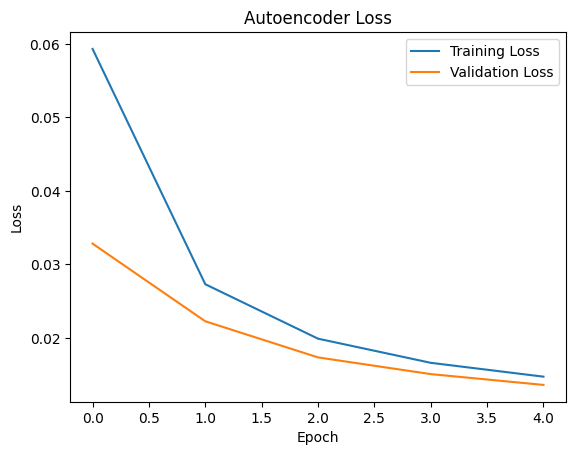

In [ ]:
autoencoder.compile(optimizer='adam', loss='mse')

# Pelatihan model
# epochs: jumlah iterasi pelatihan seluruh dataset
# batch_size: jumlah sampel per pembaruan gradien
# shuffle: mengacak data training setiap epoch
# validation_data: data yang digunakan untuk mengevaluasi loss dan metrik di akhir setiap epoch
history = autoencoder.fit(x_train, x_train,
                epochs=5,
                batch_size=256,
                shuffle=True,
                validation_data=(x_test, x_test))

# Visualisasikan riwayat pelatihan (loss)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Autoencoder Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

### Visualisasi Rekonstruksi

Mari kita lihat bagaimana autoencoder merekonstruksi beberapa citra dari dataset pengujian.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


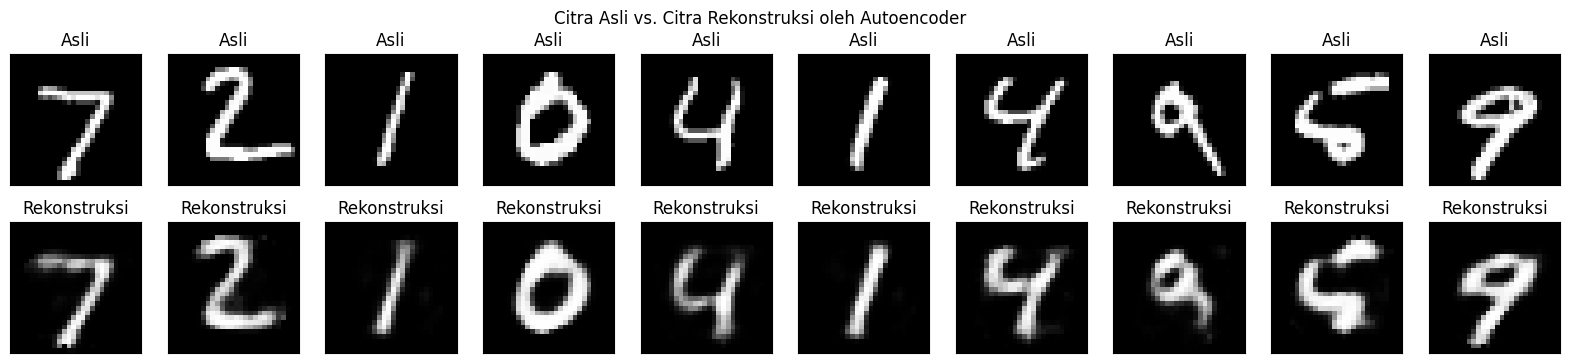

In [ ]:
# Encode dan Decode beberapa gambar dari dataset pengujian
encoded_imgs = encoder.predict(x_test)
decoded_imgs = decoder.predict(encoded_imgs)

# Tampilkan citra asli dan yang direkonstruksi
n = 10 # Jumlah citra yang akan ditampilkan
plt.figure(figsize=(20, 4))
for i in range(n):
    # Citra asli
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    ax.set_title("Asli")

    # Citra yang direkonstruksi
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    ax.set_title("Rekonstruksi")
plt.suptitle('Citra Asli vs. Citra Rekonstruksi oleh Autoencoder')
plt.show()